In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score,recall_score,f1_score,accuracy_score,confusion_matrix,ConfusionMatrixDisplay,roc_auc_score,roc_curve

In [3]:
df=pd.read_csv('C:/Users/medoc/OneDrive/Desktop/work/Machine/data/Churn_Modelling.csv')
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,1,1,1,79084.10,0


In [4]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   NumOfProducts    10000 non-null  int64  
 9   HasCrCard        10000 non-null  int64  
 10  IsActiveMember   10000 non-null  int64  
 11  EstimatedSalary  10000 non-null  float64
 12  Exited           10000 non-null  int64  
dtypes: float64(1), int64(9), object(3)
memory usage: 1015.8+ KB


In [6]:
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [7]:
df.duplicated().sum()

0

In [8]:
df['Exited'].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

In [9]:
df.drop(columns=['RowNumber','CustomerId','Surname'],axis=1,inplace=True)

In [10]:
df_dummy = pd.get_dummies(df["Geography"],dtype=int)
df_dummy.head()
df=pd.concat([df,df_dummy],axis=1)
df.drop("Geography",axis=1,inplace=True)
df.head()

,CreditScore,Gender,Age,Tenure,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,France,Germany,Spain
0,619,Female,42,2,1,1,1,101348.88,1,1,0,0
1,608,Female,41,1,1,0,1,112542.58,0,0,0,1
2,502,Female,42,8,3,1,0,113931.57,1,1,0,0
3,699,Female,39,1,2,0,0,93826.63,0,1,0,0
4,850,Female,43,2,1,1,1,79084.10,0,0,0,1


In [11]:
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])
df['Gender']

0       0
1       0
2       0
3       0
4       0
       ..
9995    1
9996    1
9997    0
9998    1
9999    0
Name: Gender, Length: 10000, dtype: int32

<Axes: >

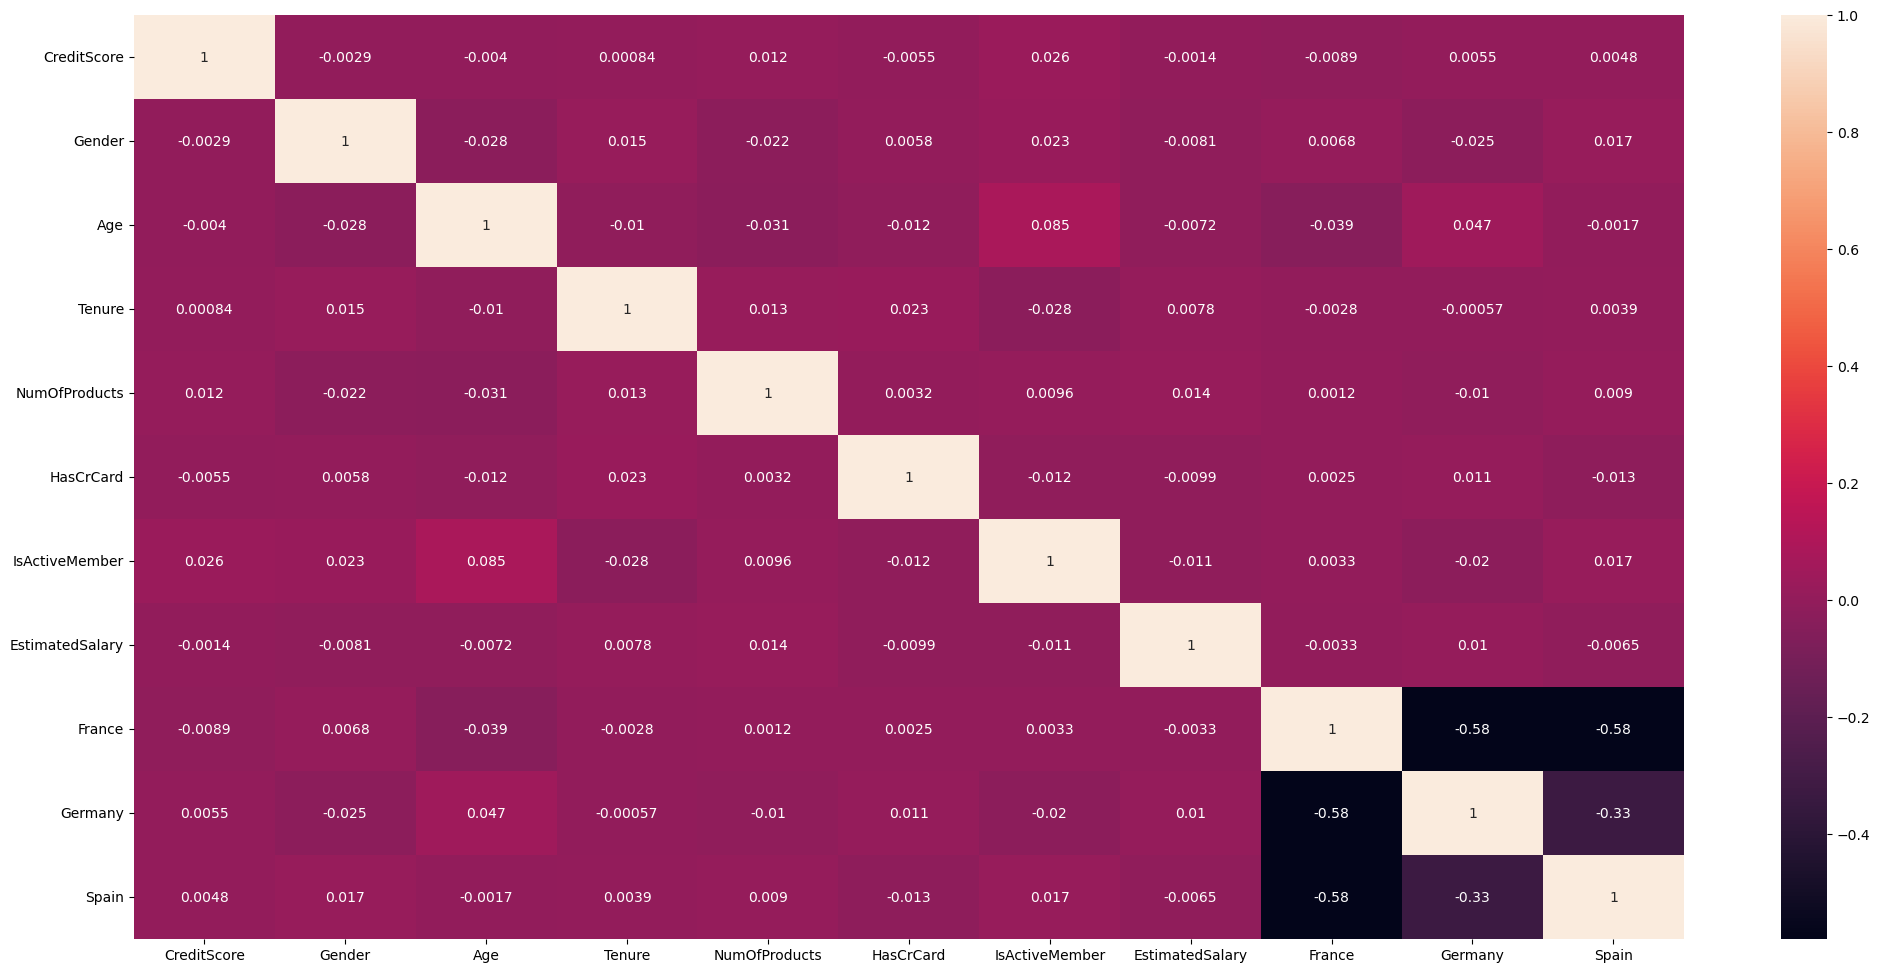

In [12]:
plt.figure(figsize=(25,12))
corr=df.drop("Exited",axis=1).corr()
sns.heatmap(corr, annot=True)

In [13]:
x=df.drop("Exited",axis=1)
y=df["Exited"]
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [14]:
stand=StandardScaler()
x_train=stand.fit_transform(x_train)
x_test=stand.transform(x_test)

In [15]:
lr = LogisticRegression()
lr.fit(x_train, y_train)

y_pred=lr.predict(x_test)

In [16]:
cm = confusion_matrix(y_test, predictions, labels=lr.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=lr.classes_)
disp.plot()
plt.show()

NameError: name 'predictions' is not defined

In [ ]:
acc=accuracy_score(y_test,y_pred)
print("accuracy=",acc*100,'%')
f1=f1_score(y_test,y_pred)
print("F1cscore=",f1*100,'%')
pre=precision_score(y_test,y_pred)
print("precision=",pre*100,'%')
rec=recall_score(y_test,y_pred)
print("recall=",rec*100,'%')

accuracy= 81.6 %
F1cscore= 30.82706766917293 %
precision= 58.992805755395686 %
recall= 20.865139949109416 %
